In [1]:
import pickle as pkl
import numpy as np
import pandas as pd 


with open('X_train.pickle', 'rb') as f:
    X_train = pkl.load(f)

with open('Y_train.pickle', 'rb') as f:
    Y_train = pkl.load(f)

with open('Y_val.pickle', 'rb') as f:
    Y_val = pkl.load(f)

with open('X_val.pickle', 'rb') as f:
     X_val = pkl.load(f)

with open('Y_test.pickle', 'rb') as f:
    Y_test = pkl.load(f)

with open('X_test.pickle', 'rb') as f:
     X_test = pkl.load(f)


Y_train = Y_train.reshape((-1,1))
Y_val = Y_val.reshape((-1,1))
Y_test = Y_test.reshape((-1,1))

X_train.shape , Y_train.shape , X_val.shape , Y_val.shape , X_test.shape , Y_test.shape

((225480, 120, 5),
 (225480, 1),
 (45000, 120, 5),
 (45000, 1),
 (135240, 120, 5),
 (135240, 1))

In [2]:
from sklearn.utils.class_weight import compute_class_weight



class_weights = compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique ( np.reshape( Y_train , (np.shape(Y_train)[0]))),
                                        y = np.reshape(Y_train ,(np.shape(Y_train)[0]))                                                 
                                    )
class_weights = dict(zip(np.unique(np.reshape(Y_train ,(np.shape(Y_train)[0]))), class_weights))
class_weights


{0: 0.9999113082039911, 1: 1.0000887075312694}

In [3]:
unique, counts_train = np.unique(Y_train, return_counts=True)
unique, counts_val = np.unique(Y_val, return_counts=True)
unique, counts_test = np.unique(Y_test, return_counts=True)

print("Number of samples per class in the training dataset:")
print(dict(zip(unique, counts_train)))

print("\nNumber of samples per class in the validation dataset:")
print(dict(zip(unique, counts_val)))

print("\nNumber of samples per class in the test dataset:")
print(dict(zip(unique, counts_test)))

Number of samples per class in the training dataset:
{0: 112750, 1: 112730}

Number of samples per class in the validation dataset:
{0: 20844, 1: 24156}

Number of samples per class in the test dataset:
{0: 61161, 1: 74079}


In [7]:
import os

filepath = "parameter_tuning_LSTM_60min.csv"

# check if the file exists, create it if not
if not os.path.isfile(filepath):
    columns_name = ['LSTM_blocks', 'learning_rate', 'regularizer', 'droput', 'optimizer', 'batch size' ,
                    'train_loss' , 'val_loss' , 'train_accuracy' , 'val_accuracy', 'test_loss' , 'test_accuracy']
    df = pd.DataFrame(columns=columns_name)  # create an empty dataframe
    df.to_csv(filepath, index=False)  # save as a CSV file with no index


In [14]:
import tensorflow
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from tensorflow.keras import regularizers
from tensorflow import keras
import numpy as np 

#reproducibility 
np.random.seed(0)
tensorflow.random.set_seed(0)

#defining hyperparameters

LSTM_blocks = 256
regularizer = 0.3
lr = 0.0005  #I think best one is 0.0001
dropout  = 0.5
batchsize = 512
optimizer_func = 'Adam'

# Define the model
def create_model(LSTM_blocks, regularizer, dropout):
    model = Sequential()
    model.add(BatchNormalization(input_shape=(120, 5)))
    model.add(LSTM(LSTM_blocks, input_shape=(120, 5) , return_sequences=False , activation='tanh', bias_regularizer=regularizers.l1(regularizer),  kernel_regularizer=regularizers.l1(regularizer)))
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    model.summary()
    return model 


model = create_model(LSTM_blocks, regularizer, dropout)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_3           │ (None, 120, 5)         │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 256)            │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,565 (1.02 MB)

 Trainable params: 268,555 (1.02 MB)

 Non-trainable params: 10 (40.00 B)

In [15]:
# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=lr,weight_decay=1e-7) if optimizer_func == 'Adam' else keras.optimizers.SGD(learning_rate=lr ,weight_decay=1e-7)

model.compile(loss='binary_crossentropy', optimizer= optimizer, metrics=['binary_accuracy' ])


checkpoint_path = 'my_best_model_LSTM_60min.keras'

checkpoint = ModelCheckpoint(filepath=checkpoint_path, 
                             monitor='val_binary_accuracy',
                             verbose=1, 
                             save_best_only=True,
                             mode='max')


earlystopping = EarlyStopping(monitor='val_binary_accuracy', patience=10, restore_best_weights=True, min_delta=0.01)

callback = [earlystopping, checkpoint]
# Train the model
history = model.fit(X_train, Y_train, validation_data=(X_val , Y_val) , verbose=1,  batch_size=batchsize, epochs=50,callbacks = callback , class_weight=class_weights)

loss, accuracy = model.evaluate(X_test, Y_test, batch_size=5000)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")



Epoch 1/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - binary_accuracy: 0.7881 - loss: 93.3284
Epoch 1: val_binary_accuracy improved from -inf to 0.81467, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - binary_accuracy: 0.7881 - loss: 93.2893 - val_binary_accuracy: 0.8147 - val_loss: 60.4192
Epoch 2/50
440/441 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - binary_accuracy: 0.8274 - loss: 56.1753
Epoch 2: val_binary_accuracy improved from 0.81467 to 0.82678, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - binary_accuracy: 0.8274 - loss: 56.1561 - val_binary_accuracy: 0.8268 - val_loss: 43.5255
Epoch 3/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - binary_accuracy: 0.8625 - loss: 39.1780
Epoch 3: val_binary_accuracy improved from 0.82678 to 0.87478, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - binary_accuracy: 0.8625 - loss: 39.1684 - val_binary_accuracy: 0.8748 - v

In [11]:
filepath = "parameter_tuning_LSTM_60min.csv"
parameters_to_save = pd.read_csv(filepath)

new_row = pd.DataFrame([{'LSTM_blocks' : LSTM_blocks, 'learning_rate': lr, 'regularizer': regularizer, 'droput': dropout, 
                         'optimizer': optimizer_func, 'batch size': batchsize, 'train_loss' : history.history['loss'][-1] ,
                         'val_loss' : history.history['val_loss'][-1] , 'train_accuracy' : history.history['binary_accuracy'][-1] , 
                         'val_accuracy' : history.history['val_binary_accuracy'][-1],'test_loss' : f"{loss:.4f}" , 
                         'test_accuracy' : f"{accuracy*100:.2f}%" }])

parameters_to_save = pd.concat([parameters_to_save, new_row], ignore_index=True)

parameters_to_save.to_csv(filepath, index=False)


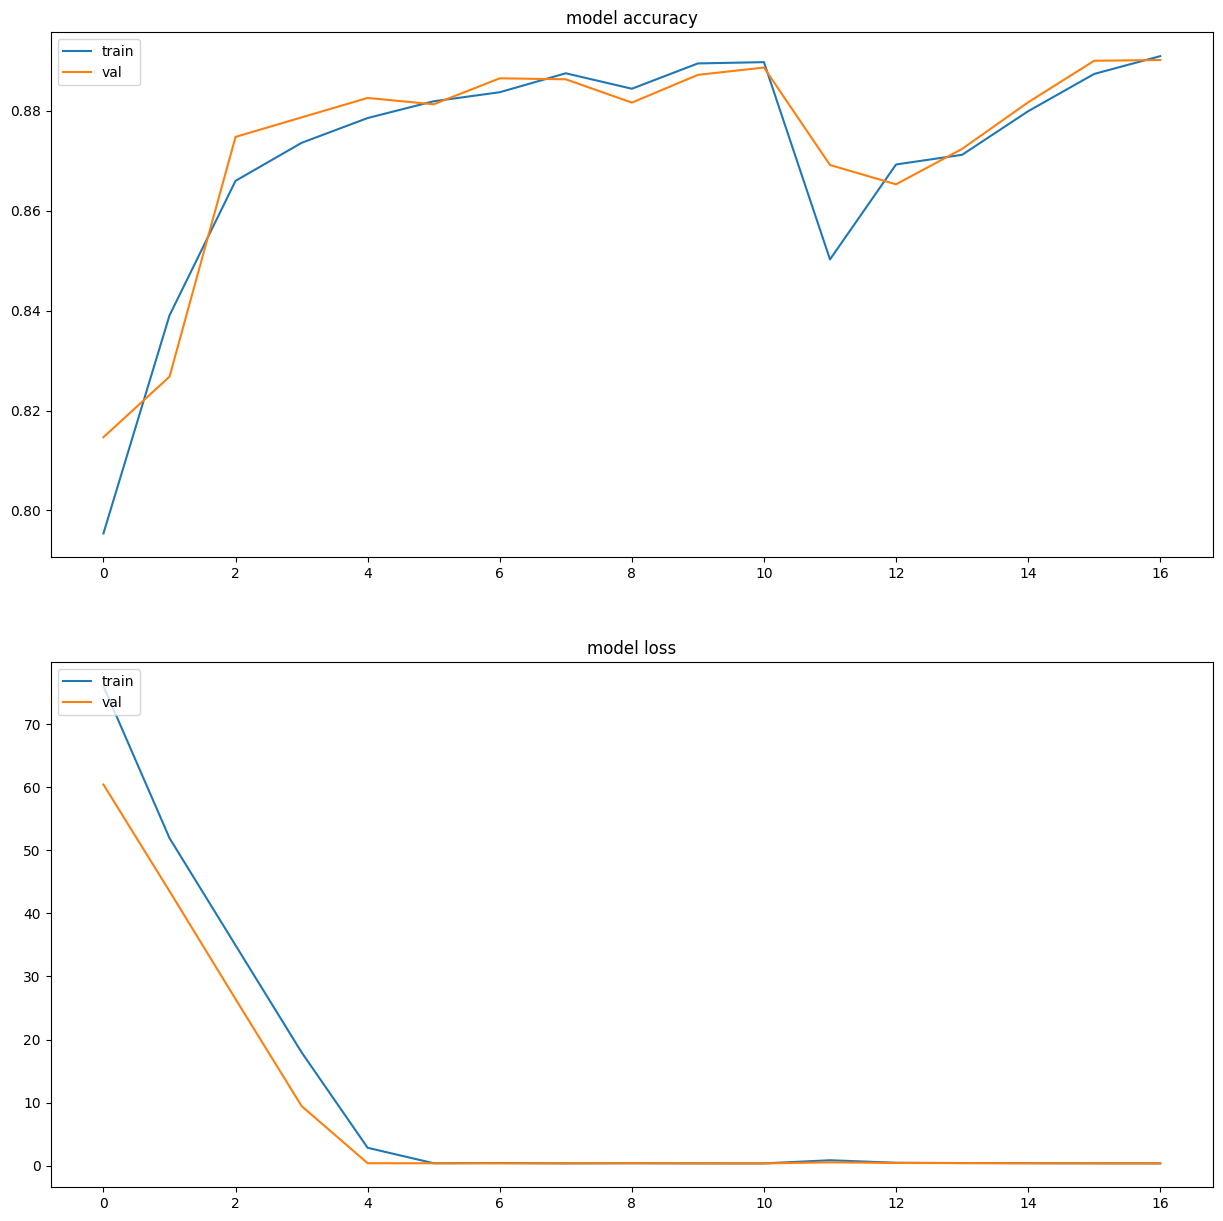

In [16]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,1, figsize = (15,15))
axs = axs.flatten()
axs[0].plot(history.history['binary_accuracy'])
axs[0].plot(history.history['val_binary_accuracy'])
axs[0].set_title('model accuracy')

axs[0].legend(['train', 'val'], loc='upper left')

# summarize history for loss
axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_title('model loss')

axs[1].legend(['train', 'val'], loc='upper left')


In [17]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Predict the labels for the test set
Y_pred = model.predict(X_test, batch_size=5000)
Y_pred = (Y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute the scores
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

# Print the results
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step
F1 Score: 0.8978
Recall: 0.9044
Precision: 0.8914
